In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Understanding
# Load the dataset (Make sure the CSV is uploaded to your Colab environment)
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("--- Data Info ---")
df.info() # Print info [cite: 13]
print("\n--- Data Describe ---")
print(df.describe()) # Print describe [cite: 13]

# Identify missing or strange values (like " ") [cite: 15]
# 'TotalCharges' often has blank spaces instead of NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

Data Cleaning


In [5]:
# 2. Data Cleaning
# Fix data types: TotalCharges is object -> float [cite: 18]
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Handle missing values (dropping them here as they are usually a tiny fraction) [cite: 19]
df.dropna(subset=['TotalCharges'], inplace=True)
print("Data cleaning complete. Missing values handled.")

Data cleaning complete. Missing values handled.


Feature Engineering

In [6]:
# 3. Feature Engineering
# Create TenureGroup [cite: 25]
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months', '61-72 months']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

# Create AvgMonthlySpend = TotalCharges / Tenure [cite: 26]
# Adding a small number to tenure to avoid division by zero if tenure is 0
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 0.0001)

# Convert binary yes/no to 1/0 (Assuming 'Churn' is the target) [cite: 27, 28]
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns like Contract, InternetService [cite: 29]
df = pd.get_dummies(df, columns=['Contract', 'InternetService'], drop_first=True)
print("Feature engineering complete. New columns added.")

Feature engineering complete. New columns added.


Exploratory Data Analysis (EDA) & Visualizations

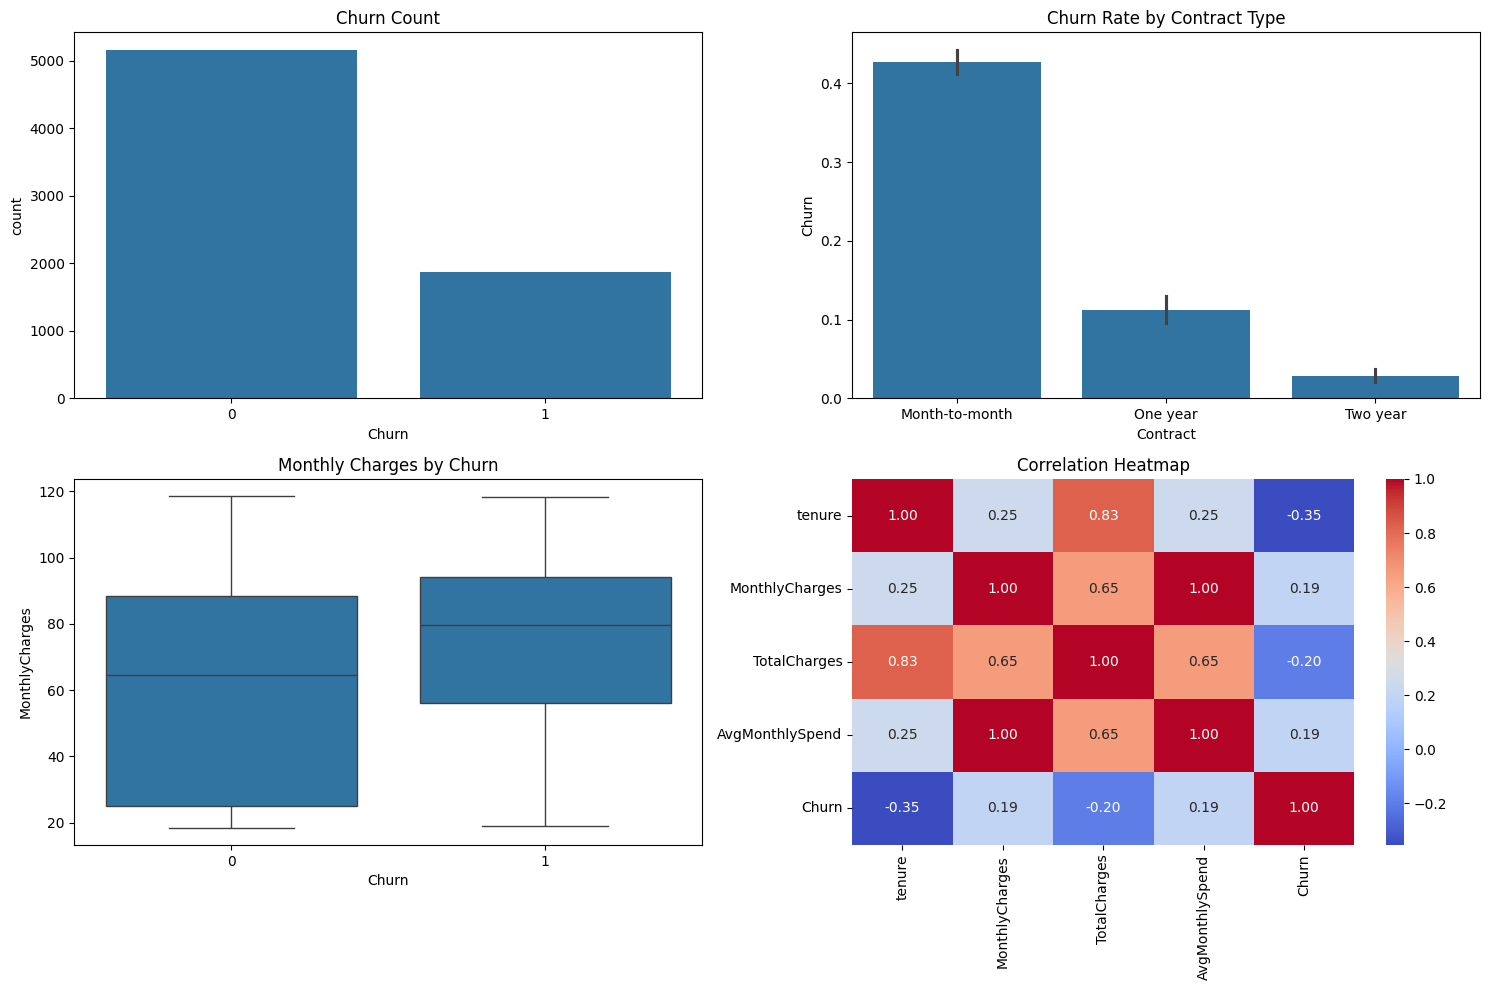

In [7]:
# 4. EDA & Visualization
plt.figure(figsize=(15, 10))

# Countplot for Churn [cite: 31]
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Churn')
plt.title('Churn Count')

# Barplot: Contract vs Churn [cite: 32]
# Using the newly created dummy variables or original if we kept it.
# Re-loading just the contract column for the plot to make it easier to read
df_plot = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
plt.subplot(2, 2, 2)
sns.barplot(data=df_plot, x='Contract', y=(df['Churn'] == 1).astype(int))
plt.title('Churn Rate by Contract Type')

# Boxplot: MonthlyCharges by Churn [cite: 35]
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')

# Heatmap of correlations (selecting a few numeric columns to avoid clutter) [cite: 34]
plt.subplot(2, 2, 4)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'Churn']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

Deliverables

In [8]:
# 5. Deliverables
# Save Cleaned.csv file [cite: 40]
df.to_csv("Cleaned_Churn_Data.csv", index=False)
print("Data cleaned and saved to 'Cleaned_Churn_Data.csv'. You can now download it from the Colab file explorer.")

Data cleaned and saved to 'Cleaned_Churn_Data.csv'. You can now download it from the Colab file explorer.
